# <center>**Combination of Data Analysis of TNFa,IL_1b** </center>

## **Import the essential libraries** 

In [1]:
from pathlib import Path
from typing import List, Dict
import pandas as pd
from matplotlib import pyplot as plt
import statistics as st
import statsmodels.api as sm
import numpy as np
import random as rd
import os
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## **Setup output format** 

In [2]:
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 30)

## **Declare the output folder**

In [3]:
result_folder="result4_ex_plate2"
os.makedirs(result_folder, exist_ok=True)
result_path=Path.cwd()/result_folder
print(result_path)

D:\IPPTPAN\Project\Population effect of Macrophase\Manuscript_Data\result4_ex_plate2


## **Load input data** 

In [4]:
# load quantifications
file_path22 = "IF22_co.pkl.gz"
quant_df22 = pd.read_pickle(file_path22, compression='gzip')
quant_df22['circularity_normalized'] = quant_df22['circularity'] / quant_df22['nuc_area']**0.2 #Add circularity normalized by area
quant_df22["ExID"]="IF22"
quant_df22.columns
quant_df22=quant_df22.loc[quant_df22.index.get_level_values("Plate")!=2].copy() # Exclude plate number 2
print(quant_df22.index.get_level_values("Well").unique(),len(quant_df22.index.get_level_values("Well").unique()))


Index(['0103', '0104', '0105', '0106', '0107', '0108', '0109', '0110', '0203',
       '0204', '0205', '0206', '0207', '0208', '0209', '0210', '0303', '0304',
       '0305', '0306', '0307', '0308', '0309', '0310', '0403', '0404', '0405',
       '0406', '0407', '0408', '0409', '0410', '0503', '0504', '0505', '0506',
       '0507', '0508', '0509', '0510', '0603', '0604', '0605', '0606', '0607',
       '0608', '0609', '0610', '0703', '0704', '0705', '0706', '0707', '0708',
       '0709', '0710', '0803', '0804', '0805', '0806', '0807', '0808', '0809',
       '0810'],
      dtype='object', name='Well') 64


In [5]:
quant_df22.index.get_level_values("Plate").unique()

Index([1, 3, 4], dtype='int64', name='Plate')

In [6]:
file_path24 = "IF24_co.pkl.gz"
quant_df24 = pd.read_pickle(file_path24, compression='gzip')
quant_df24['circularity_normalized'] = quant_df24['circularity'] / quant_df24['nuc_area']**0.2 #Add circularity normalized by area
quant_df24["ExID"]="IF24"
quant_df24=quant_df24.loc[quant_df24.index.get_level_values("Plate")!=3].copy() # Exclude plate number 3
new_index = quant_df24.index.set_levels(
    quant_df24.index.levels[quant_df24.index.names.index("Plate")] + 4, 
    level="Plate"
)
quant_df24.index = new_index
quant_df24.columns
print(quant_df24.index.get_level_values("Well").unique(),len(quant_df24.index.get_level_values("Well").unique()))

Index(['0102', '0103', '0104', '0105', '0106', '0107', '0108', '0109', '0110',
       '0202', '0203', '0204', '0205', '0206', '0207', '0208', '0209', '0210',
       '0303', '0304', '0305', '0306', '0307', '0308', '0309', '0310', '0403',
       '0404', '0405', '0406', '0407', '0408', '0409', '0410', '0503', '0504',
       '0505', '0506', '0507', '0508', '0509', '0510', '0603', '0604', '0605',
       '0606', '0607', '0608', '0609', '0610', '0703', '0704', '0705', '0706',
       '0707', '0708', '0709', '0710', '0803', '0804', '0805', '0806', '0807',
       '0808', '0809', '0810'],
      dtype='object', name='Well') 66


In [7]:
quant_df=pd.concat([quant_df22,quant_df24])
quant_df = quant_df.sort_index()

### **Verifing the Data**

In [8]:
quant_df.columns

Index(['nuc_area', 'nuc_area_masked', 'nuc_eccentricity', 'nuc_is_toggled',
       'nuc_center_x', 'nuc_center_y', 'nuc_il1b_intensity_min',
       'nuc_il1b_intensity_max', 'nuc_il1b_intensity_median',
       'nuc_il1b_intensity_quartile1',
       ...
       'per_dna_intensity_h2_mean', 'per_dna_intensity_inertia',
       'per_dna_intensity_sum', 'origin', 'solidity', 'circularity',
       'longest_hv_stretch', 'distance_to_corner', 'circularity_normalized',
       'ExID'],
      dtype='object', length=135)

In [9]:
quant_df.index.get_level_values("Well").unique()

Index(['0103', '0104', '0105', '0106', '0107', '0108', '0109', '0110', '0203',
       '0204', '0205', '0206', '0207', '0208', '0209', '0210', '0303', '0304',
       '0305', '0306', '0307', '0308', '0309', '0310', '0403', '0404', '0405',
       '0406', '0407', '0408', '0409', '0410', '0503', '0504', '0505', '0506',
       '0507', '0508', '0509', '0510', '0603', '0604', '0605', '0606', '0607',
       '0608', '0609', '0610', '0703', '0704', '0705', '0706', '0707', '0708',
       '0709', '0710', '0803', '0804', '0805', '0806', '0807', '0808', '0809',
       '0810', '0102', '0202'],
      dtype='object', name='Well')

In [10]:
quant_df.shape

(1101786, 135)

### **Applying Constrains for Data Cleaning**

In [11]:
TO_UM2 = 0.598**2 # remove nuclei that are too small or too large
MIN_AREA_UM2, MAX_AREA_UM2= 25, 225
quant_df = quant_df[ (MIN_AREA_UM2 <= quant_df["nuc_area"]*TO_UM2) & (quant_df["nuc_area"]*TO_UM2 <= MAX_AREA_UM2) ]
ECC=0.3 # remove nuclei that are not round - eccentricity > 0.3)
quant_df=quant_df[quant_df["nuc_eccentricity"] <ECC]
CN0=0.145 # remove nuclei that are not circular 
quant_df=quant_df[quant_df["circularity_normalized"] > CN0]
HV0=12 # remove nuclei that are flat on one side 
quant_df=quant_df[quant_df["longest_hv_stretch"] <= HV0]
D0=100 # remove nuclei that are close to the edge (in  pixels) 
quant_df=quant_df[quant_df["distance_to_corner"] > D0]
# remove nuclei for which there is no perinuclei
a=len(quant_df)
quant_df = quant_df[quant_df['per_area'] != 0]
print('Removed',a-len(quant_df[quant_df['per_area'] != 0]),'nuclei')
print("Total number of nuclei are removed",a)


Removed 13915 nuclei
Total number of nuclei are removed 957527


### **Manually Enumerate Different Treatment Conditions In The Main DataFrame**

In [12]:
# Define a function to assign the 'Lipid A' condition based on the well
def assign_lipid_a_condition(well):
    if well.startswith('01') or well.startswith('03') or well.startswith('05') or well.startswith('07') :
        return 'Mock'
    elif well.startswith('02') or well.startswith('04') or well.startswith('06') or well.startswith('08'):
        return '500 ng/mL'
    else:
        return 'Unknown'  # Optional, for wells not starting with '0' or '03'

def assign_cells_well_condition(well):
    if well.startswith('01') or well.startswith('02') or well.startswith('03') or well.startswith('04'):
        return 20
    elif well.startswith('05') or well.startswith('06') or well.startswith('0709') or well.startswith('0710') or \
         well.startswith('0809') or well.startswith('0704') or well.startswith('0810'):
         return 500
    elif well.startswith('0707') or well.startswith('0708') or well.startswith('0807') or well.startswith('0808'):
         return 2500 
    elif well.startswith('0705') or well.startswith('0706') or well.startswith('0805') or well.startswith('0806') :
         return 5000
    elif well.startswith('0703') or well.startswith('0704') or well.startswith('0803') or well.startswith('0804') :
         return 10000
    else:
         return 'Unknown'  # Optional, for wells not starting with '0' or '03'

def assign_staining_condition(well,ExID):
    if ExID=="IF22" and (well.startswith('0103') or well.startswith('0203')):
            return 'No'
    elif ExID=="IF24" and (well.startswith('0102') or well.startswith('0202')):
           return 'No'
    else:
           return 'Yes'

# Add columns for new conditions
#clones_df = clones_df.reset_index()
quant_df = quant_df.copy()  # Ensure we work with a copy

quant_df.loc[:, 'Lipid A'] = [

    
    assign_lipid_a_condition(well)
    for well in quant_df.index.get_level_values('Well').astype(str)
]
quant_df.loc[:, 'Cells_well'] = [
    assign_cells_well_condition(well)
    for well in quant_df.index.get_level_values('Well').astype(str)
]



quant_df["Staining"] = [
    assign_staining_condition(str(well), exid)
    for well, exid in zip(
        quant_df.index.get_level_values("Well").astype(str),
        quant_df["ExID"].astype(str)
    )
]


quant_df

nuc_area  nuc_area_masked  nuc_eccentricity  \
Plate Well Clone nucleus_id                                                
1     0103 -1    43             298.0              0.0             0.103   
                 64             281.0              0.0             0.041   
                 202            227.0              0.0             0.174   
                 219            205.0              0.0             0.100   
                 414            120.0              0.0             0.060   
...                               ...              ...               ...   
8     0810 -1    659            303.5              0.0             0.044   
                 660            440.5              0.0             0.234   
                 666            351.0              0.0             0.218   
                 667            392.5              0.0             0.182   
                 668            272.0              0.0             0.107   

                             nuc_is_toggled  nuc_center_x  nuc_center_y  \
Plate Well Clone nucleus_id                                               
1     0103 -1    43                       0       5540.97       9111.69   
                 64                       0       5575.79       9046.82   
                 202                      0       8577.42       7724.41   
                 219                      0       8557.69       1542.93   
                 414                      0       7165.08        401.13   
...                                     ...           ...           ...   
8     0810 -1    659                      0       6589.86       2035.90   
                 660                      0       6530.49       1090.84   
                 666                      0       7542.05        636.38   
                 667                      0       7532.41        652.51   
                 668                      0       4722.00        124.98   

                             nuc_il1b_intensity_min  nuc_il1b_intensity_max  \
Plate Well Clone nucleus_id                                                   
1     0103 -1    43                              10                      14   
                 64                              10                      14   
                 202                             10                      26   
                 219                             10                      15   
                 414                              9                      12   
...                                             ...                     ...   
8     0810 -1    659                             20                      70   
                 660                             27                      98   
                 666                             25                      63   
                 667                             21                      61   
                 668                             27                      69   

                             nuc_il1b_intensity_median  \
Plate Well Clone nucleus_id                              
1     0103 -1    43                                 12   
                 64                                 12   
                 202                                15   
                 219                                12   
                 414                                11   
...                                                ...   
8     0810 -1    659                                41   
                 660                                68   
                 666                                35   
                 667                                34   
                 668                                47   

                             nuc_il1b_intensity_quartile1  \
Plate Well Clone nucleus_id                                 
1     0103 -1    43                                    11   
                 64                                    11   
                 202                 

In [13]:
quant_df[(quant_df["Staining"] == "No") & (quant_df["ExID"]=="IF24")].index.get_level_values("Well").unique()

Index(['0102', '0202'], dtype='object', name='Well')

In [14]:
quant_df[(quant_df["Staining"] == "No") & (quant_df["ExID"]=="IF22")].index.get_level_values("Well").unique()

Index(['0103', '0203'], dtype='object', name='Well')

## **Create a clean Data File**

In [15]:
# quant_df.to_pickle('IFs_36-38--Plate_series1clean.pkl')

In [16]:
quant_df.to_pickle('tnfa_il1b_clean_exclude_plate2_and_7.pkl')

## **Experiment settings**

In [17]:
# # Experiment settings
# #EXPERIMENT_FOLDER = "IF38"  # Main folder containing experiment data
# PLATE_FOLDER = "IF38_Plate1A2 "  # Specific subfolder to process
# layout_dfs = []

# # Path to the specific plate folder
# plate_path = Path.cwd()

# # Path to WellsInfo.pkl
# layout_path = plate_path /'WellsInfo1.pkl'

# # Process the specific file if it exists
# if layout_path.exists():
#     try:
#         layout_df = pd.read_pickle(layout_path)
#         layout_df.replace('N/A', pd.NA, inplace=True)
#         layout_df['Experiment'] = PLATE_FOLDER  # Add folder name as experiment identifier
#         layout_df = layout_df.reset_index().set_index(['Experiment', 'Row', 'Column'])
#         for integer_col in ['Days_in_culture', 'Cells_well']:
#             layout_df[integer_col] = layout_df[integer_col].astype(int)
#         layout_dfs.append(layout_df)
#     except Exception as e:
#         print(f"Error processing file: {layout_path}. Error: {e}")
# else:
#     print(f"File not found: {layout_path}")

# # Combine the DataFrame (only one in this case)
# if layout_dfs:
#     layout_df = pd.concat(layout_dfs)
# layout_df.index

# Sort data into clones and daughter cells

In [18]:
#Clone cells
clean_df = quant_df.loc[
    (quant_df.index.get_level_values('Clone') >= 0) & (quant_df['Staining'] == 'Yes')
]

# Daughter  cells
clean_df1=quant_df.loc[
    (quant_df['Cells_well'] == 500) & (quant_df['Staining'] == 'Yes')
]
# Mix 2500
clean_df2=quant_df.loc[
    (quant_df['Cells_well'] == 2500) & (quant_df['Staining'] == 'Yes')
]
# Mix 5000
clean_df3=quant_df.loc[
    (quant_df['Cells_well'] == 5000) & (quant_df['Staining'] == 'Yes')
]
# Density_controls
clean_df4=quant_df.loc[
    (quant_df['Cells_well'] == 10000) & (quant_df['Staining'] == 'Yes')
]

combined_df = pd.concat([clean_df, clean_df1,clean_df2,clean_df3,clean_df4])

In [19]:
# clean_df1.to_pickle('IF36_Plate_series1_mixed_cells.pkl') 

In [20]:
clean_df1.to_pickle('tnfa_ilb_daughter_cells.pkl')

In [21]:
# combined_df.to_pickle('IFs_36-38_plate_series1_clean_cells.pkl')

In [22]:
combined_df.to_pickle('combine_clean_cells.pkl')

In [23]:
# quant_df_if22=combined_df.loc[combined_df["ExID"]=='IF22'].copy()
# quant_df_if22.to_pickle('combine_clean_cells_if22.pkl')

In [24]:
# quant_df_if24=combined_df.loc[combined_df["ExID"]=='IF24'].copy()
# quant_df_if24.to_pickle('combine_clean_cells_if24.pkl')

## **Display overview of clean data**

In [25]:
def experiment_plot(combined_df):
    combined_df_exid=combined_df
    plate_clones_df = combined_df_exid.loc[3,:,:,:]
    plate_clones_well_ids = plate_clones_df.index.get_level_values('Well').unique().sort_values()
    plate_clones_well_ids
    # show an overview of clusters
    NCOLS = 11  # Columns from 3 to 10
    NROWS = 9  # Rows from 2 to 8
    
    fig_mosaic = [[f"{r + 0:02d}{c + 0:02d}" for c in range(3,NCOLS)] for r in range(1,NROWS)]
    fig_opts = dict(sharex=True, sharey=True, figsize=(NCOLS*1.5, NROWS*1.5))
    scatter_opts = dict(s=0.3, alpha=0.4, edgecolors='none')
    annot_opts = dict(xy=(0.5, 0.91), xycoords='axes fraction', ha='center', alpha=0.5)
    sides = ('top', 'right', 'left', 'bottom')
    unique_plates = combined_df_exid.index.get_level_values("Plate").unique()
    print(unique_plates)
    for plate in unique_plates:
        plate_clones_df = combined_df_exid.loc[plate, :, :, :]
        plate_clones_well_ids = plate_clones_df.index.get_level_values('Well').unique().sort_values()
        
        fig, axes = plt.subplot_mosaic(fig_mosaic, **fig_opts)
        
        for _, ax in axes.items():
            ax.set_axis_off()
        
        for well in plate_clones_well_ids:
            ax.set_aspect('equal', adjustable='box')
            ax = axes[well]
            ax.set_axis_on()
            for s in sides: ax.spines[s].set_linewidth(0.25)
            ax.set_xticks([]);  ax.set_yticks([])
            ax.set_xlabel('');  ax.set_ylabel('')
            ax.annotate(text=f"{well}", **annot_opts)
    
            well_data = plate_clones_df.loc[well, :, :]
            clones_well_data    = well_data.loc[ well_data.index.get_level_values('Clone') >= 0, :]
            nonclones_well_data = well_data.loc[ well_data.index.get_level_values('Clone') <  0, :]
            
            x, y = nonclones_well_data[['nuc_center_x', 'nuc_center_y']].values.T
            ax.scatter(x, -y, c='gray', **scatter_opts)
            
            x, y = clones_well_data[['nuc_center_x', 'nuc_center_y']].values.T
            c = clones_well_data.index.get_level_values('Clone')
            ax.scatter(x, -y, c=c, cmap='gist_rainbow', **scatter_opts)
    
        fig.suptitle(f"Plate {plate}: Overview of Clusters")
        
        # Instead of fig.tight_layout():
        #fig.tight_layout(h_pad=-0.15, w_pad=-0.1);
        fig.subplots_adjust(wspace=0, hspace=0.02, left=0.01, right=0.78, top=0.95, bottom=0.01)
        #fig.savefig(f"plate_overview--expt--plate_{plate}.png", dpi=600);

Index([1, 3, 4, 5, 6, 8], dtype='int64', name='Plate')


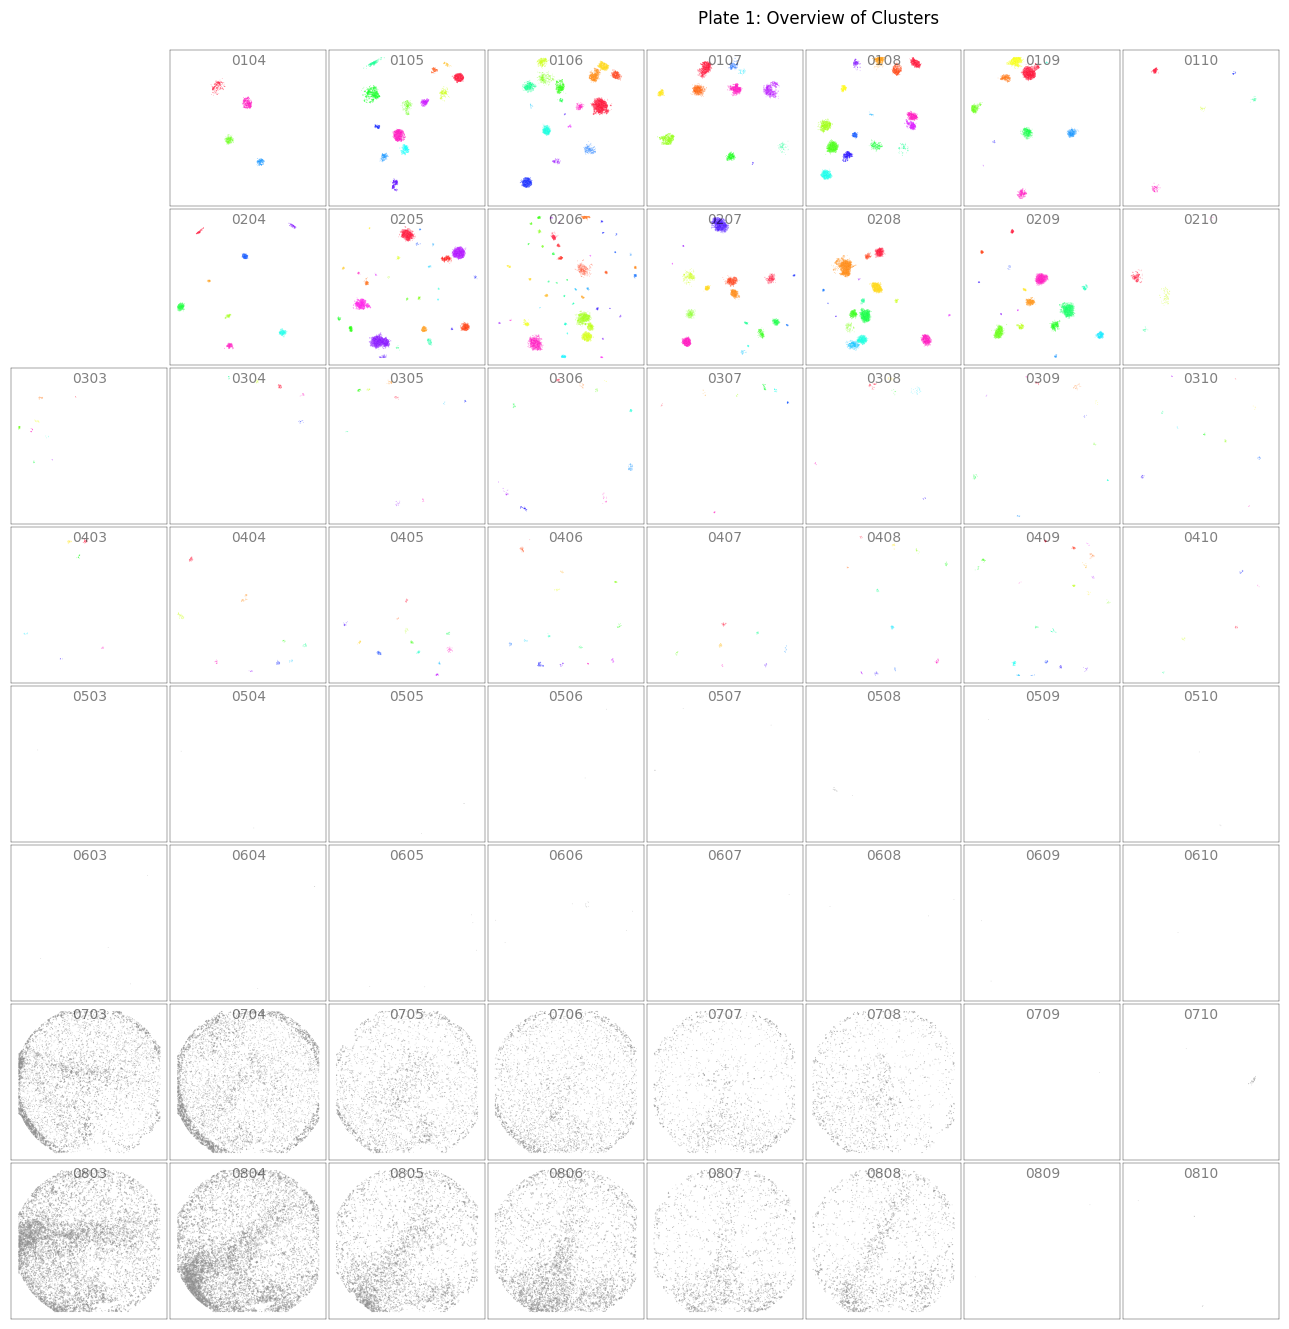

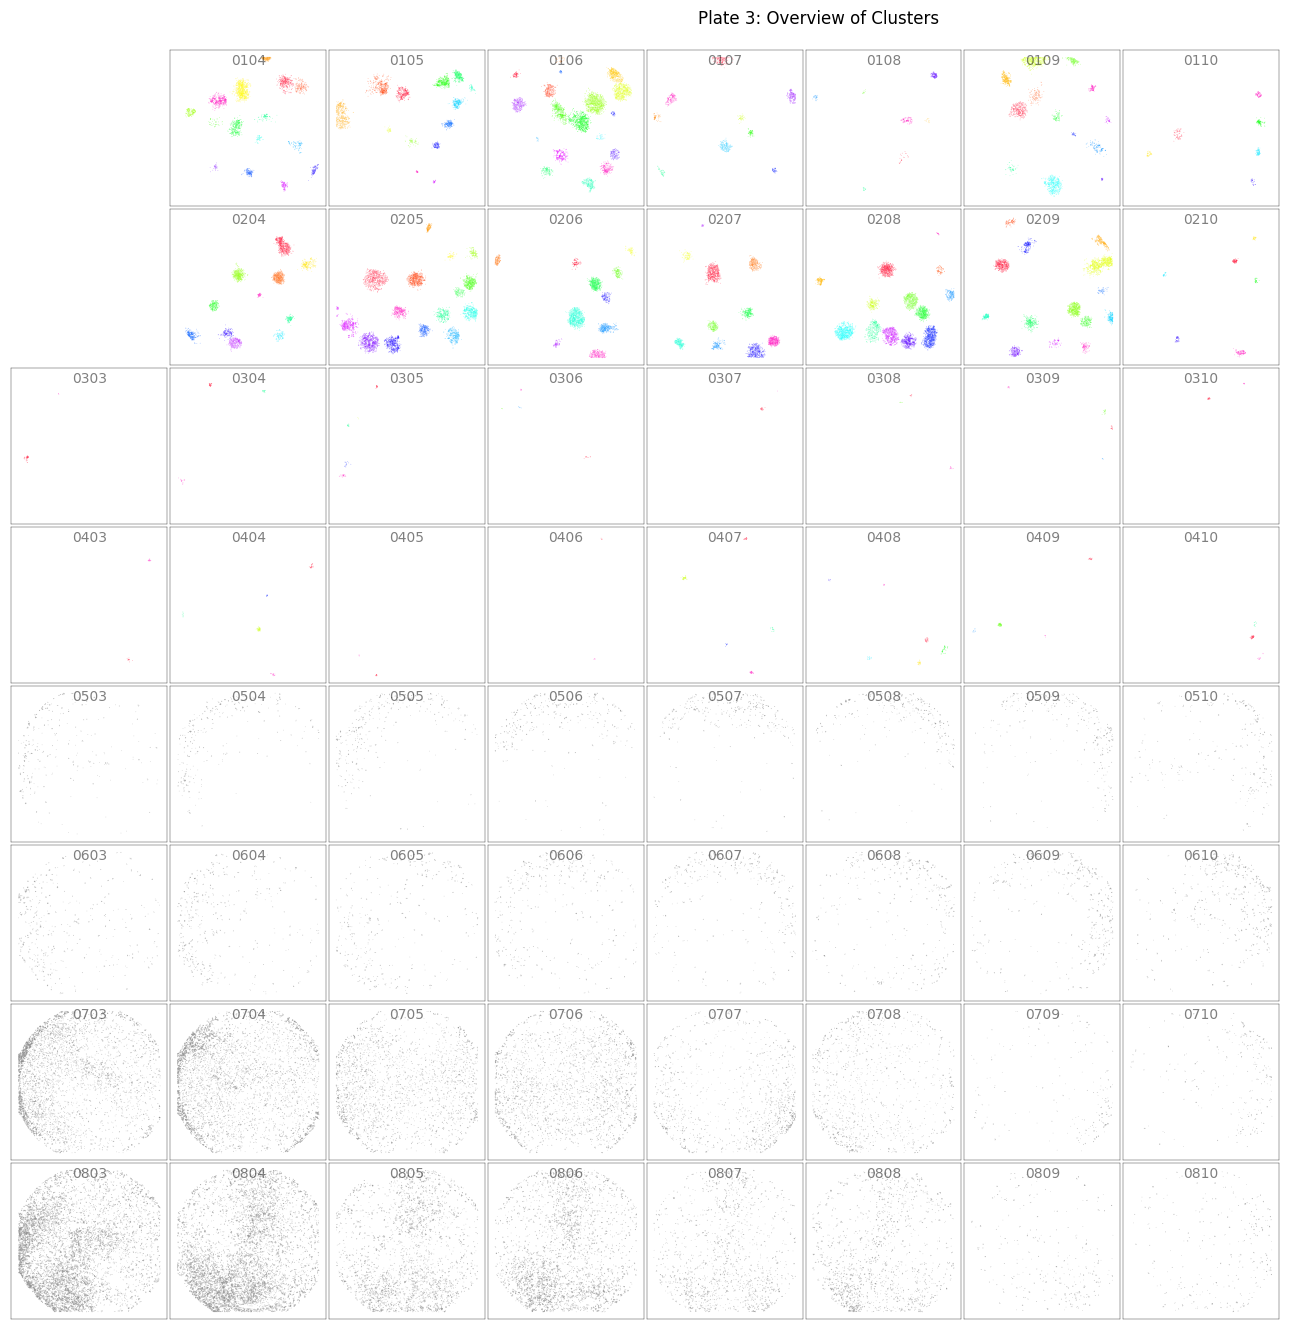

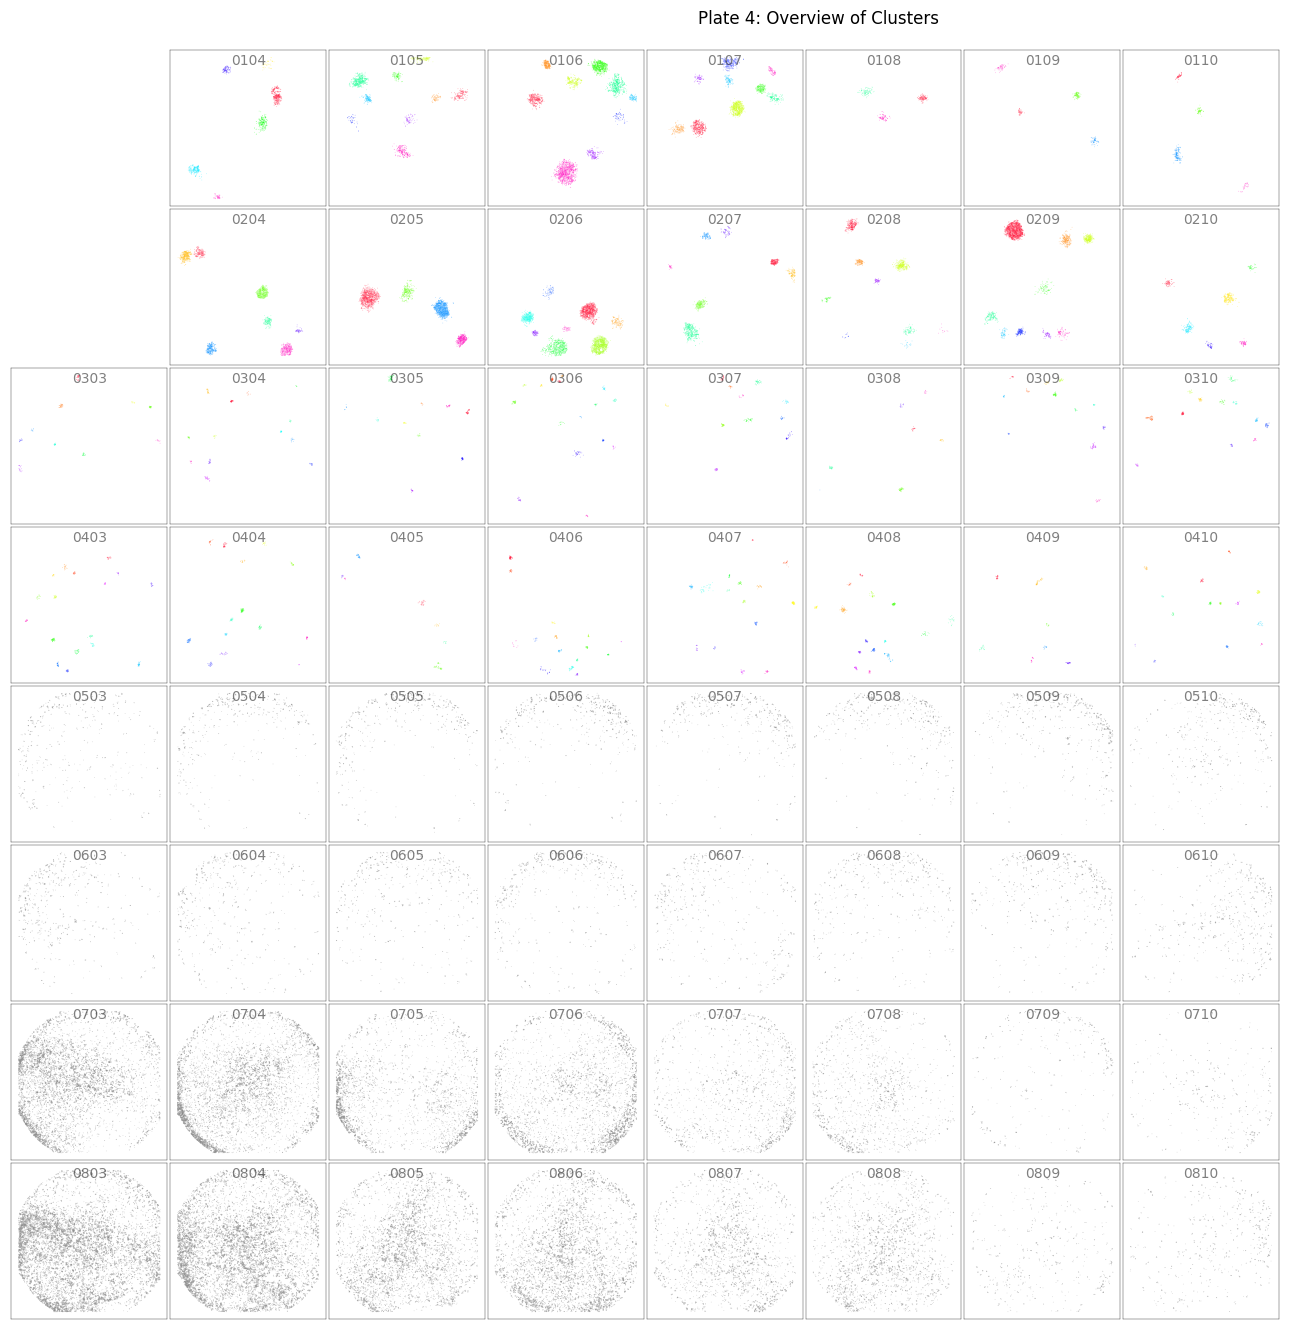

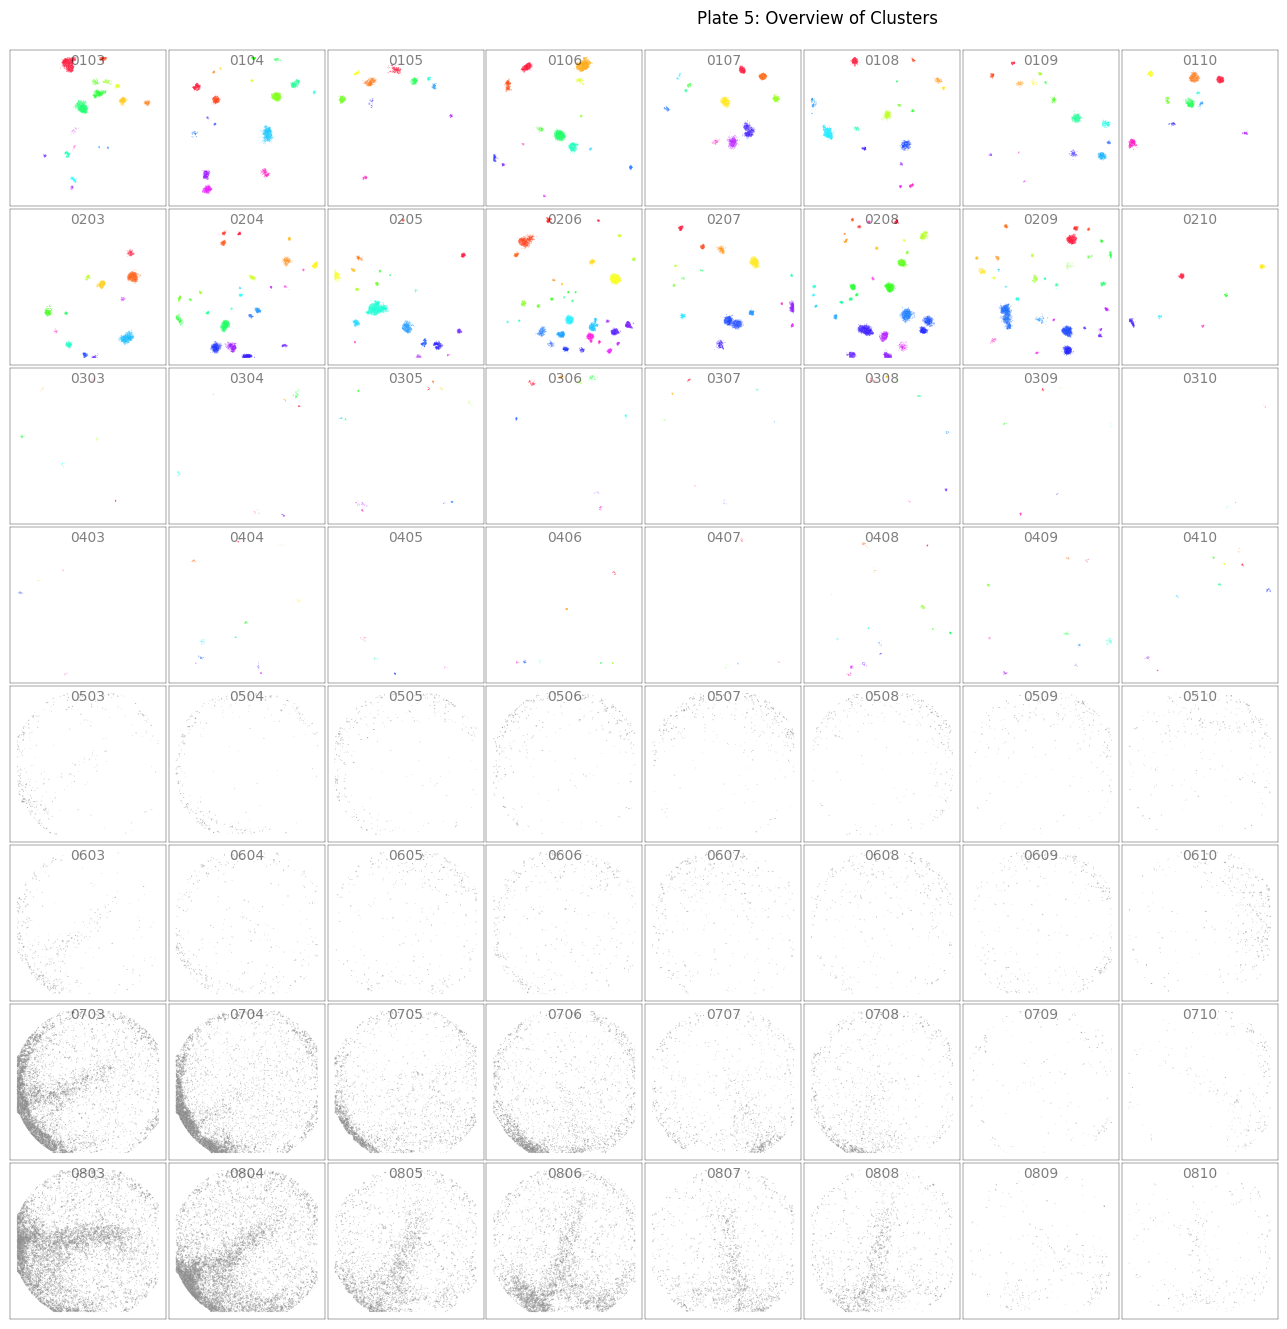

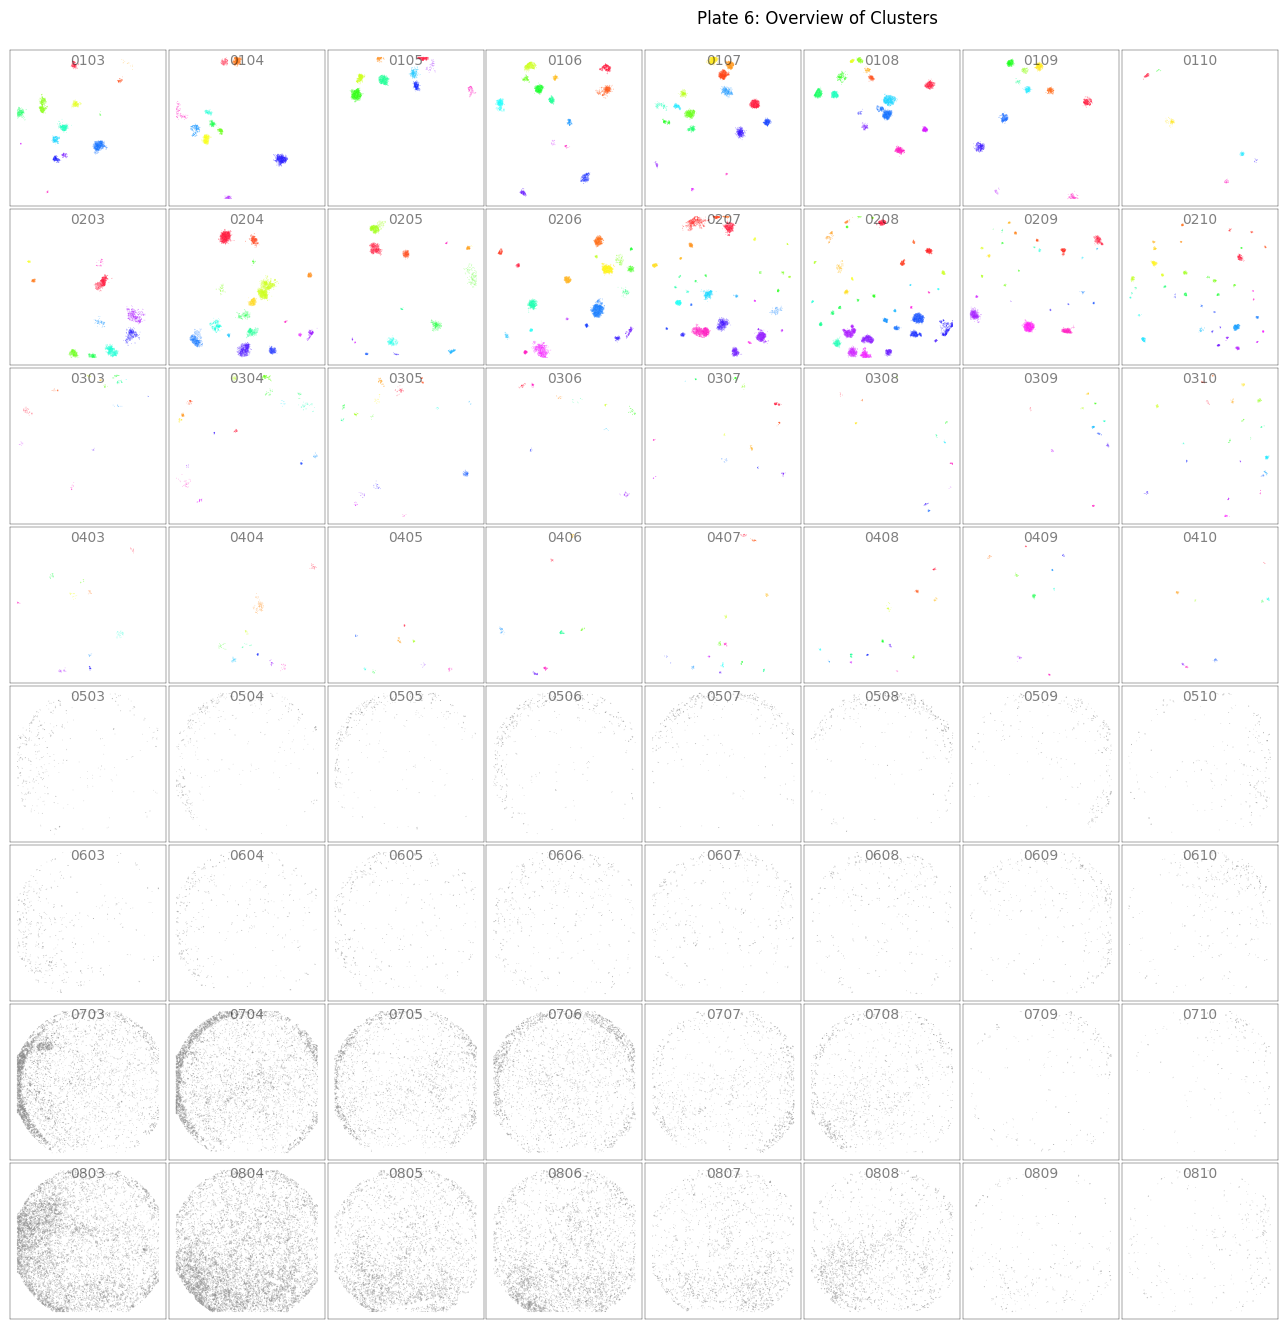

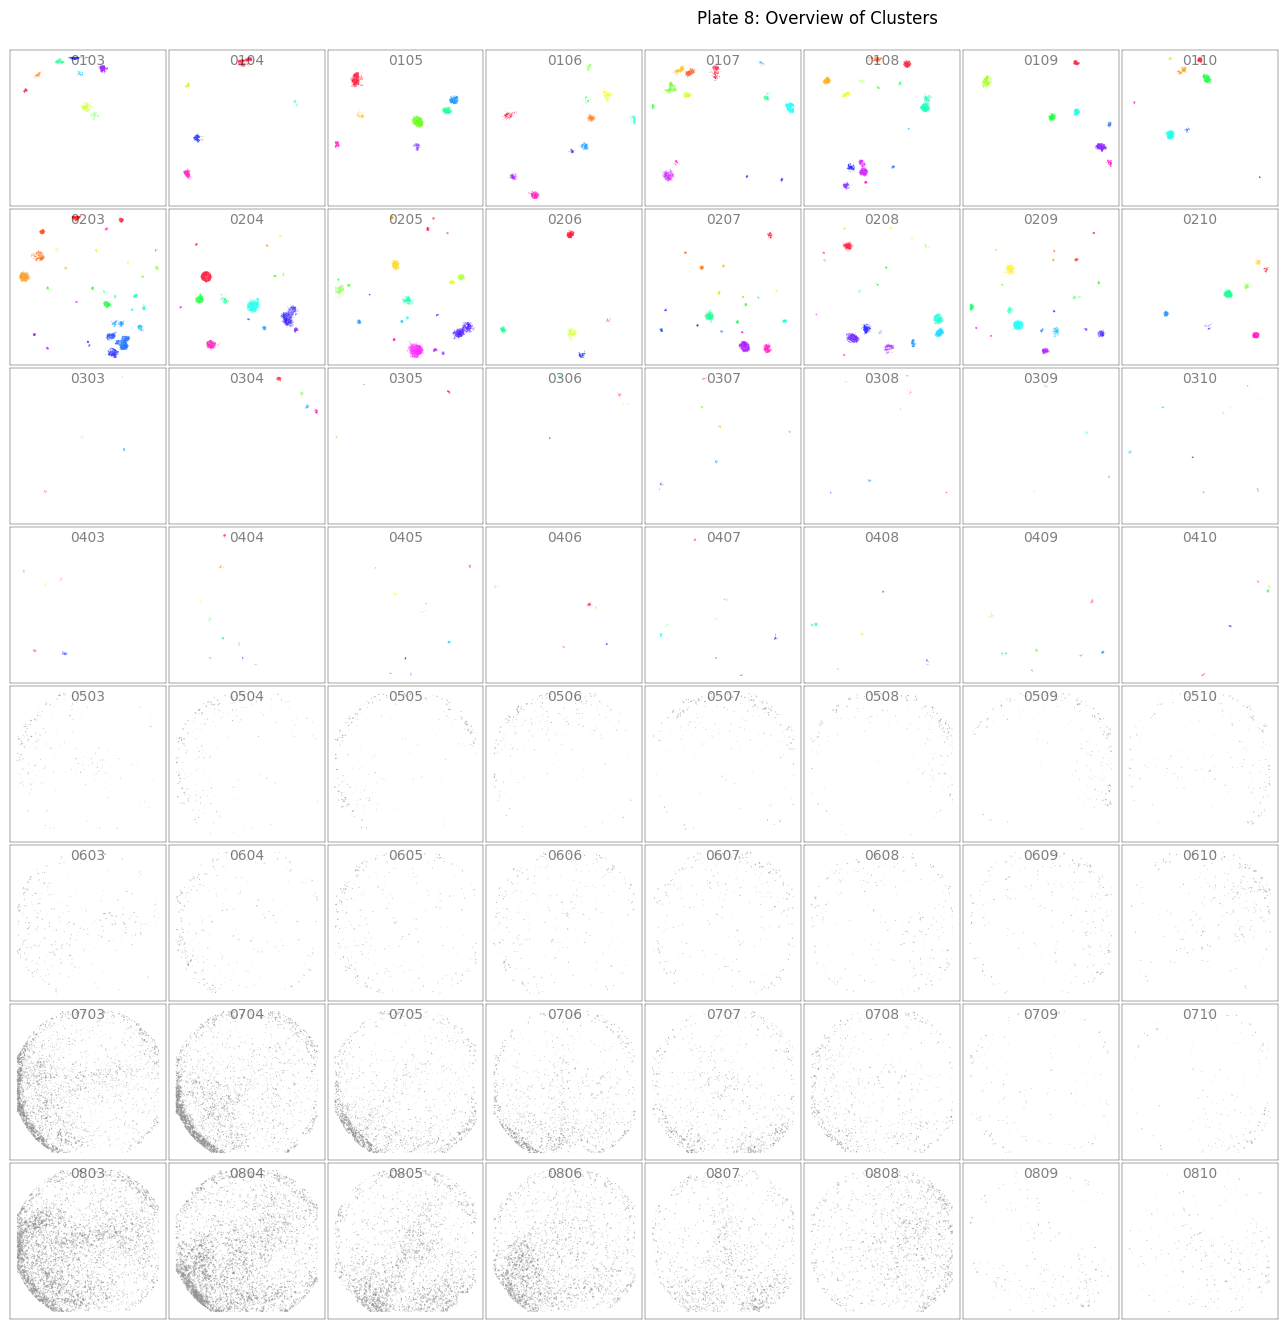

In [26]:
experiment_plot(combined_df)